In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

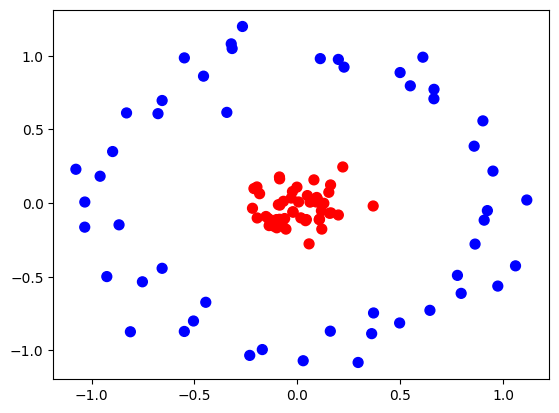

In [8]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [11]:
classifier=SVC(kernel='linear')
classifier.fit(X_train,y_train.ravel())
y_pred= classifier.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score 
accuracy_score(y_test,y_pred)

0.55

In [15]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_58/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


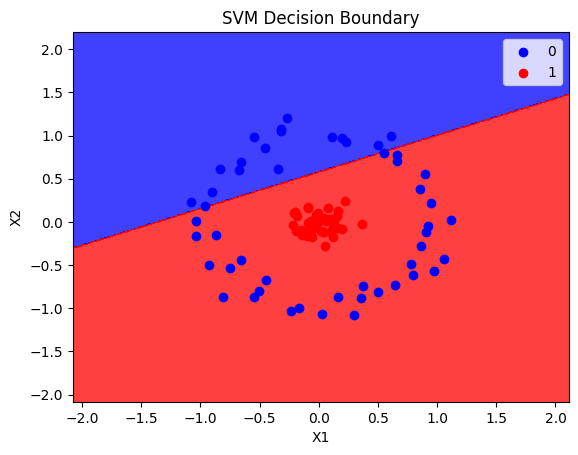

In [16]:
plot_decision_boundary(X,y,classifier)

In [17]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

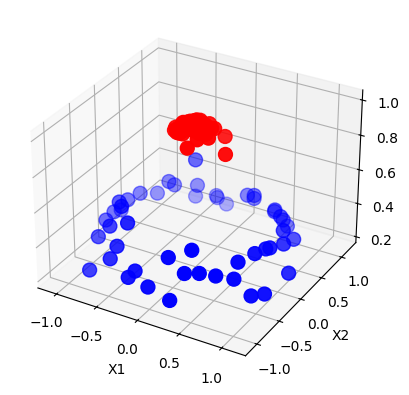

In [18]:
plot_3d_plot(X,y)

In [19]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train,y_train)
y_pred=rbf_classifier.predict(X_test)

In [20]:
accuracy_score(y_test,y_pred)

1.0

/tmp/ipykernel_58/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


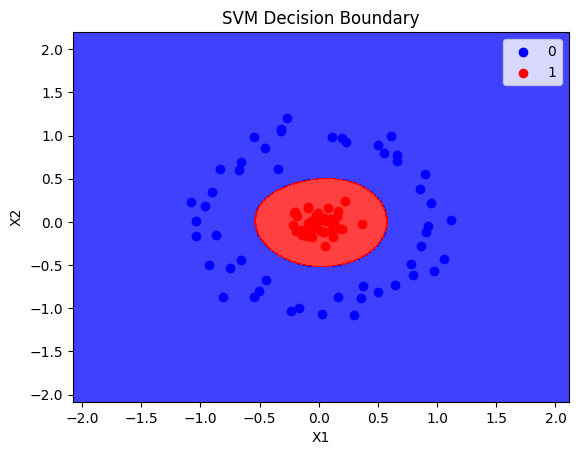

In [21]:
plot_decision_boundary(X,y, rbf_classifier)

In [23]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [24]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_58/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


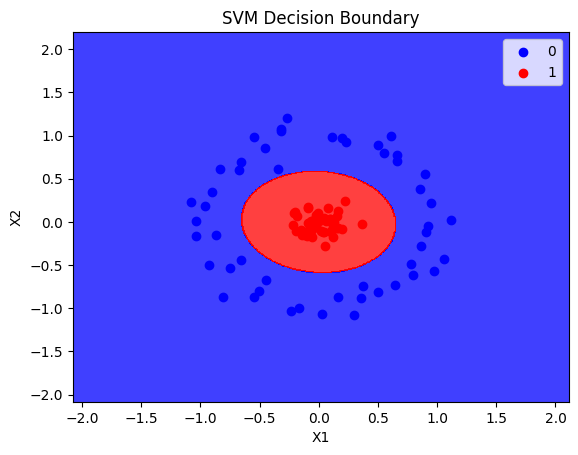

In [25]:
plot_decision_boundary(X, y, poly_classifier)

In [26]:
X

array([[ 0.04853429,  0.05073178],
       [ 0.29516687, -1.08210178],
       [-0.34281121,  0.61545869],
       [ 0.09402799,  0.0379519 ],
       [-0.1372618 , -0.15301143],
       [ 0.36841271, -0.01991796],
       [-0.0021622 ,  0.10807645],
       [-0.023927  ,  0.07811673],
       [-0.07382277, -0.14945021],
       [ 0.85911899,  0.3860538 ],
       [-1.03302616,  0.0070298 ],
       [-0.65729196,  0.69602248],
       [ 0.08040571,  0.1573782 ],
       [ 0.06148498,  0.00616753],
       [ 0.9016306 ,  0.5578408 ],
       [ 0.02823957, -1.07028273],
       [ 1.11497947,  0.02070916],
       [ 0.79598648, -0.61302115],
       [ 0.66404968,  0.77193727],
       [ 0.05683851, -0.27708916],
       [-0.54932267,  0.98535396],
       [ 0.37017925, -0.74600185],
       [ 0.11140757,  0.98034575],
       [ 0.15633614, -0.069355  ],
       [ 0.66352069,  0.70782939],
       [-0.54946416, -0.87152383],
       [ 0.36104681, -0.88641825],
       [-0.19656481,  0.10925923],
       [-0.02207895,

In [27]:
np.exp(-(X**2)).sum(1)

array([1.99507679, 1.22663792, 1.57381295, 1.9897584 , 1.95819503,
       1.87268349, 1.98838276, 1.99334402, 1.97247724, 1.33956503,
       1.34394046, 1.26522573, 1.96909209, 1.9961887 , 1.17613045,
       1.31726606, 1.28803689, 1.217424  , 1.19449063, 1.92286965,
       1.11825245, 1.44514278, 1.37014549, 1.97105671, 1.24978001,
       1.20727913, 1.33356747, 1.95023258, 1.99604233, 1.18970613,
       1.21292785, 1.39977562, 1.27085185, 1.45023271, 1.97161244,
       1.99259653, 1.98521366, 1.96601884, 1.98968917, 1.95458189,
       1.47102229, 1.9693046 , 1.33153259, 1.96160115, 1.99795445,
       1.98422188, 1.97626648, 1.99991126, 1.95225629, 1.98984689,
       1.94676235, 1.32399561, 1.29105385, 1.97660345, 1.98359167,
       1.23711772, 1.20363624, 1.96263236, 1.06462775, 1.96283502,
       1.28838463, 1.44413709, 1.34333482, 1.95526751, 1.42525734,
       1.99574748, 1.99529641, 1.1589241 , 1.26266471, 1.11511304,
       1.36627567, 1.96609274, 1.301723  , 1.98560424, 1.95240

In [28]:
x_new=np.exp(-(X**2))

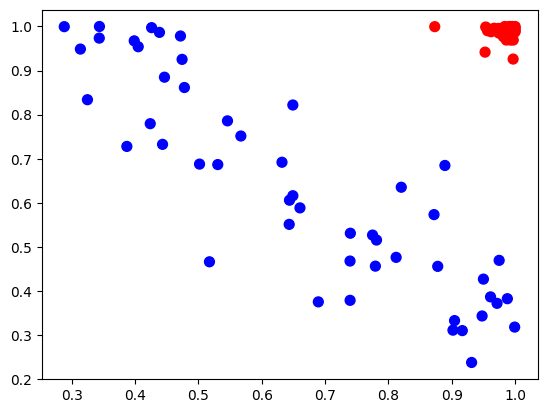

In [30]:
plt.scatter(x_new[:,0], x_new[:,1], c=y, s=50, cmap='bwr')